In [13]:
from subprocess import check_call
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
DATA_PREFIX = "../data"

TRAIN = f"{DATA_PREFIX}/train.csv"
TEST = f"{DATA_PREFIX}/test.csv"

TRAIN_ZARR = f"{DATA_PREFIX}/kaggle_train.zarr"
TEST_ZARR = f"{DATA_PREFIX}/kaggle_test.zarr"

OUTPUT_PREFIX = "../output"

In [5]:
# read zarr
train_xd = xr.open_zarr(TRAIN_ZARR)
train_xd

<xarray.Dataset> Size: 2GB
Dimensions:                                  (tile_id: 178, y: 300, x: 300)
Coordinates:
  * tile_id                                  (tile_id) StringDType() 3kB '038...
  * y                                        (y) float64 2kB 2.246e+06 ... 2....
  * x                                        (x) float64 2kB 3.111e+06 ... 3....
    spatial_ref                              int64 8B ...
Data variables: (12/16)
    angle_palsar_xxxx                        (tile_id, y, x) float32 64MB ...
    b02_s2.cdse.quarterly_xxxx0401_xxxx0631  (tile_id, y, x) float64 128MB ...
    b04_s2.cdse.quarterly_xxxx0401_xxxx0631  (tile_id, y, x) float64 128MB ...
    b08_s2.cdse.quarterly_xxxx0401_xxxx0631  (tile_id, y, x) float64 128MB ...
    biomass                                  (tile_id, y, x) float32 64MB ...
    bioregion                                (tile_id, y, x) float32 64MB ...
    ...                                       ...
    qa_palsar_xxxx                           (tile_id, y, x) float32 64MB ...
    vh.sentinel1_xxxx07                      (tile_id, y, x) float64 128MB ...
    vv.sentinel1_xxxx07                      (tile_id, y, x) float64 128MB ...
    x_coord                                  (tile_id, y, x) float64 128MB ...
    y_coord                                  (tile_id, y, x) float64 128MB ...
    year                                     (tile_id, y, x) int64 128MB ...

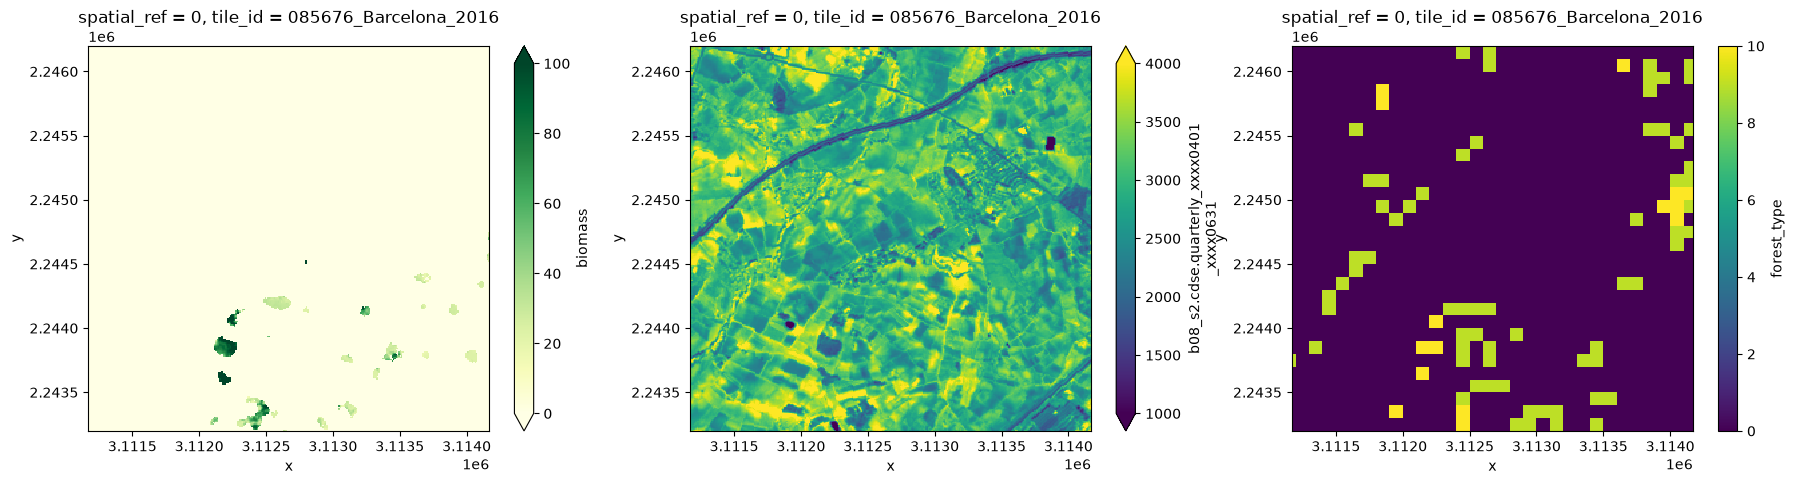

In [25]:
plt.figure(figsize=(22, 5))

# tile select
tile = 10

# check only the n data
tile = train_xd.isel(tile_id=tile)

# plot
ax = plt.subplot(1, 3, 1)
tile["biomass"].plot(cmap="YlGn", vmin=0, vmax=100)

# plot
ax = plt.subplot(1, 3, 2)
tile["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"].plot(vmin=1000, vmax=4000)

# plot
ax = plt.subplot(1, 3, 3)
tile["forest_type"].plot()

In [ ]:
train_parquet = f"{OUTPUT_PREFIX}/train.parquet"
check_call(
    f"""gdal vector make-point --x=x --y=y --output-crs=EPSG:4326 -f Parquet {TRAIN} {train_parquet} """,
    shell=True,
    text=True,
)
